<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 4 — Cluster Characterization</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">This notebook translates the final numerical cluster labels into interpretable customer segments using spend, behavioural, demographic, complaint and geographic profiles.</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Segment sizes</li>
<li>Spend profile</li>
<li>Behavioural and demographic profile</li>
<li>Loyalty, gender and household checks</li>
<li>Normalised comparison</li>
<li>Radar profile summary</li>
<li>Feature by feature plots</li>
<li>Main differentiators by cluster</li>
<li>Cluster interpretation and naming rationale</li>
<li>Geographic check</li>
<li>Final segment names</li>
<li>Export ID and cluster mapping</li>
</ol>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Characterization logic.</b><br><br>
This notebook does not change the clusters created in the modelling stage. Its purpose is to translate the numerical labels into meaningful customer groups. For that reason, every name is based on repeated evidence across spend, promotion behaviour, demographics, loyalty and service indicators.
</div>

In [71]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils_cluster_characterization as ucc

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = Path("../datasets")
df = ucc.load_characterization_data(DATA_DIR)
print("Characterization dataset shape:", df.shape)
df.head()

PROJECT_PALETTE = ['#B87540', '#B2543D', '#7E6A43', '#A8B7BA', '#D8C0B4', '#C8AB8C', '#5A3516', '#B98F70']
sns.set_theme(style='whitegrid', palette=PROJECT_PALETTE)

Characterization dataset shape: (33038, 42)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Segment sizes</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The first check is the size of each segment. Very small clusters would require caution because they may represent niche behaviour or residual outlier structure rather than stable customer segments.</p>
</div>

,cluster,cluster_name,customers,share_%
0,0,Regulars,6365,19.3
1,1,Families,3662,11.1
2,2,Economizers,5062,15.3
3,3,Vegetarians,3740,11.3
4,4,Loyalists,3393,10.3
5,5,Techies,3199,9.7
6,6,Wellness,3323,10.1
7,7,Promoters,4294,13.0


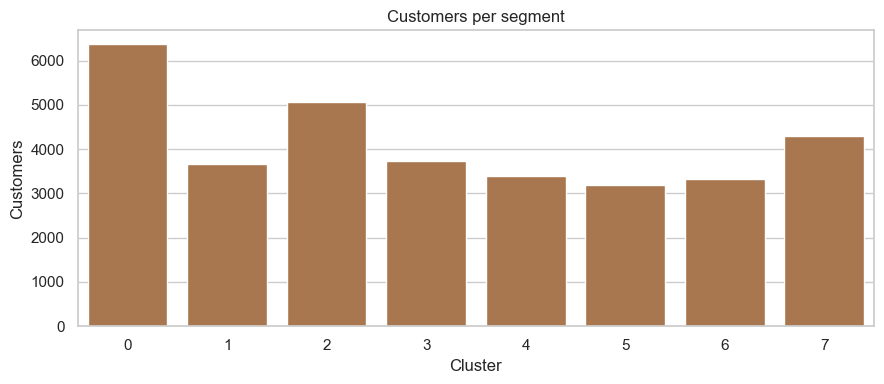

In [72]:
size_profile = ucc.cluster_sizes(df)
display(size_profile)
ucc.plot_cluster_sizes(size_profile)


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Spend profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Absolute lifetime spend by category is used to understand the main purchasing orientation of each segment. These variables are kept in original units for interpretability.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why absolute spend is still useful here.</b><br><br>
The clustering model avoids giving too much weight to dominant variables, but the interpretation stage should still look at the real spending levels. Absolute spend helps identify whether a segment is commercially relevant, while the normalised comparison later shows which categories are most distinctive within each group.
</div>

,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood
cluster,,,,,,,,,,
0,17925.41,1250.77,521.22,339.12,362.21,795.01,679.55,752.91,228.95,396.14
1,25350.54,4916.93,804.92,820.40,1502.20,1494.33,1332.62,920.01,430.12,361.80
2,12767.66,1146.85,355.37,259.67,580.98,614.13,434.94,458.41,233.61,273.83
3,10693.80,2017.33,2007.23,418.01,413.08,74.53,88.95,714.51,234.66,261.29
4,29411.55,3128.34,334.74,716.27,708.70,1013.02,1001.11,1290.76,336.41,366.91
5,9831.10,10611.46,181.35,562.32,1099.44,916.65,863.16,252.10,1456.21,302.39
6,12216.14,831.96,1508.72,611.55,167.75,162.17,117.63,2017.15,150.46,415.24
7,12886.40,1096.10,404.02,242.05,414.07,718.21,419.90,480.40,226.03,304.48
OVERALL,16306.23,2764.96,727.51,464.35,622.00,723.78,608.14,820.45,374.20,336.26


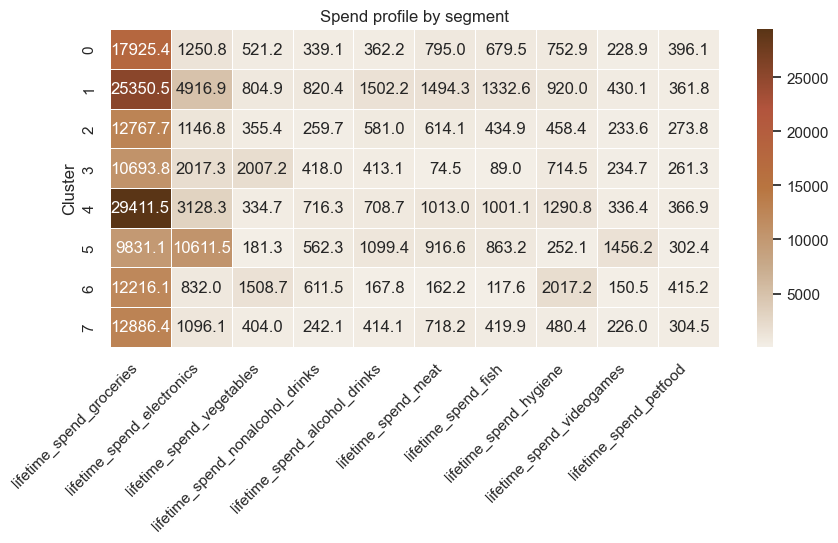

In [73]:
spend_cols = ucc.spend_columns(df)
spend_profile = ucc.profile_table(df, spend_cols)
display(spend_profile)
ucc.plot_profile_heatmap(spend_profile, "Spend profile by segment")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Behavioural and demographic profile</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This table adds non spend variables such as promotion usage, product diversity, age, education, tenure, children and complaints. These variables are not all used to fit the clustering model, but they are essential to understand who the customers are and to assign defensible business names to the final segments.</p>
</div>

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,tenure,total_children,number_complaints,customer_loyalty_flag
cluster,,,,,,,,
0,10.02,0.17,2.54,153.34,12.02,1.59,0.75,0.63
1,10.64,0.21,3.26,294.43,13.12,5.35,0.93,0.68
2,9.73,0.47,3.65,112.95,9.23,1.54,1.11,0.48
3,9.80,0.11,3.20,83.95,11.46,1.92,0.78,0.58
4,10.53,0.50,3.94,238.47,13.49,1.98,1.11,0.77
5,10.50,0.26,1.52,113.47,9.08,0.64,1.06,0.49
6,9.82,0.17,3.57,121.69,9.71,1.89,0.57,0.59
7,9.70,0.86,3.71,93.95,9.93,1.44,1.03,0.64
OVERALL,10.05,0.35,3.17,148.91,11.01,1.99,0.91,0.60


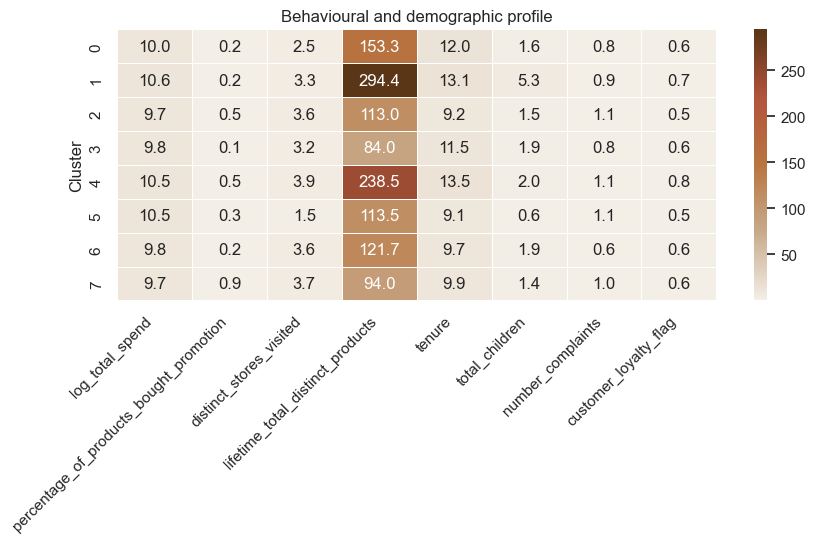

In [74]:
profile_cols = ucc.behavioural_profile_columns(df)
behaviour_profile = ucc.profile_table(df, profile_cols)
display(behaviour_profile)
ucc.plot_profile_heatmap(behaviour_profile, "Behavioural and demographic profile")

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Loyalty, gender and household checks</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0;">These plots check whether the final clusters also differ in simple customer attributes that were useful in previous segmentation work.</p>
</div>

/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/clustering/utils_cluster_characterization.py:308: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.barplot(data=summary, x=cluster_col, y="share_%", hue="feature", palette=[MAIN_COLOR, SECONDARY_COLOR, NOTE_COLOR])


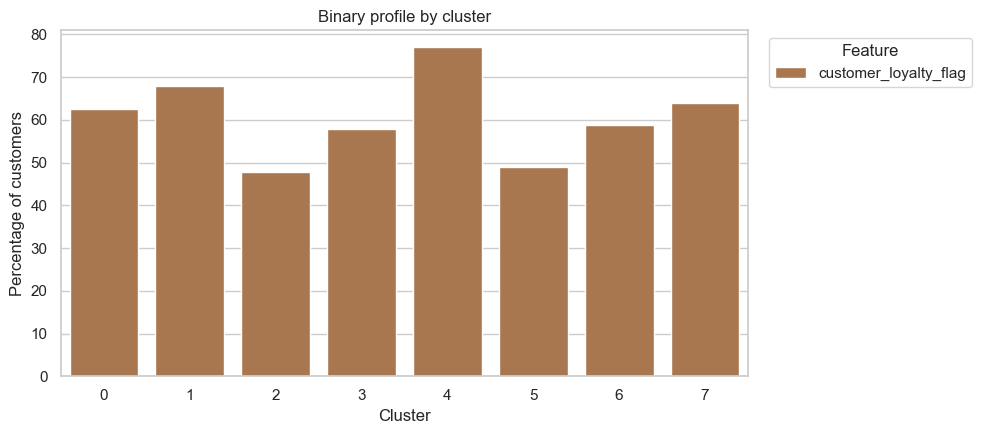

,cluster,feature,share_%
0,0,customer_loyalty_flag,62.6
1,1,customer_loyalty_flag,68.0
2,2,customer_loyalty_flag,47.8
3,3,customer_loyalty_flag,57.8
4,4,customer_loyalty_flag,77.1
5,5,customer_loyalty_flag,48.9
6,6,customer_loyalty_flag,58.7
7,7,customer_loyalty_flag,63.9


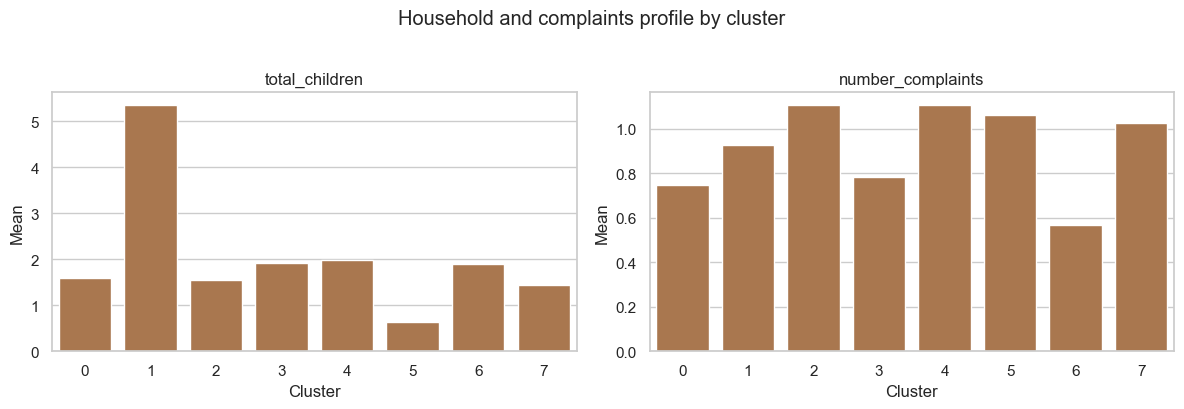

,cluster,total_children,number_complaints
0,0,1.59,0.75
1,1,5.35,0.93
2,2,1.54,1.11
3,3,1.92,0.78
4,4,1.98,1.11
5,5,0.64,1.06
6,6,1.89,0.57
7,7,1.44,1.03


In [75]:
binary_summary, household_summary = ucc.plot_simple_profile_checks(df)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Normalised comparison</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Because the variables have different units, a min max scaled comparison is used to identify which clusters are highest or lowest on each feature.</p>
</div>

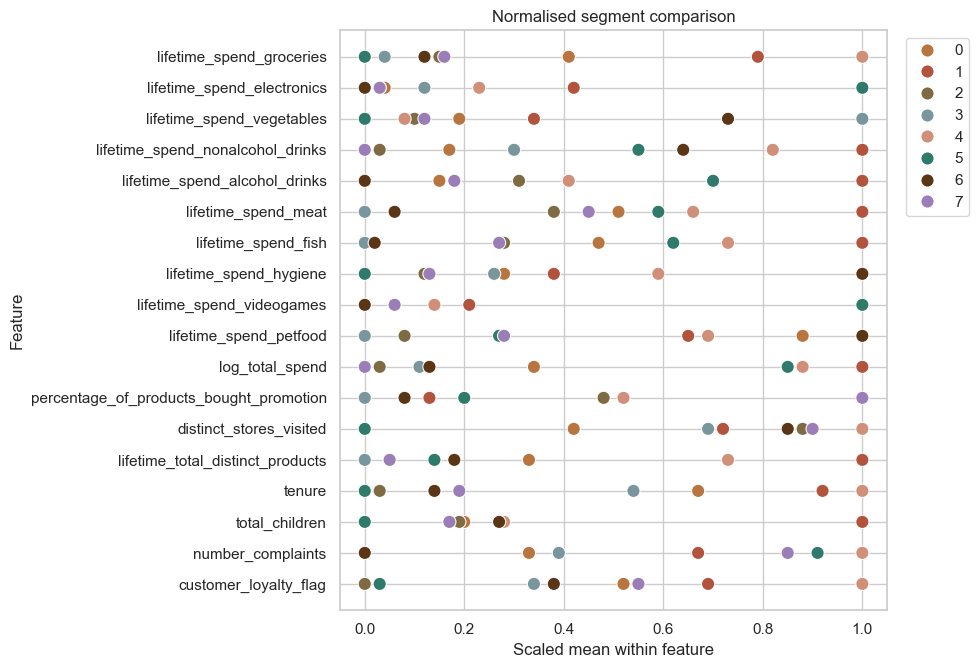

,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,tenure,total_children,number_complaints,customer_loyalty_flag
cluster,,,,,,,,,,,,,,,,,,
0,0.41,0.04,0.19,0.17,0.15,0.51,0.47,0.28,0.06,0.88,0.34,0.08,0.42,0.33,0.67,0.20,0.33,0.52
1,0.79,0.42,0.34,1.00,1.00,1.00,1.00,0.38,0.21,0.65,1.00,0.13,0.72,1.00,0.92,1.00,0.67,0.69
2,0.15,0.03,0.10,0.03,0.31,0.38,0.28,0.12,0.06,0.08,0.03,0.48,0.88,0.14,0.03,0.19,1.00,0.00
3,0.04,0.12,1.00,0.30,0.18,0.00,0.00,0.26,0.06,0.00,0.11,0.00,0.69,0.00,0.54,0.27,0.39,0.34
4,1.00,0.23,0.08,0.82,0.41,0.66,0.73,0.59,0.14,0.69,0.88,0.52,1.00,0.73,1.00,0.28,1.00,1.00
5,0.00,1.00,0.00,0.55,0.70,0.59,0.62,0.00,1.00,0.27,0.85,0.20,0.00,0.14,0.00,0.00,0.91,0.03
6,0.12,0.00,0.73,0.64,0.00,0.06,0.02,1.00,0.00,1.00,0.13,0.08,0.85,0.18,0.14,0.27,0.00,0.38
7,0.16,0.03,0.12,0.00,0.18,0.45,0.27,0.13,0.06,0.28,0.00,1.00,0.90,0.05,0.19,0.17,0.85,0.55


In [76]:
combined_profile = ucc.profile_table(df, spend_cols + profile_cols)
scaled_profile = ucc.plot_scaled_profile(combined_profile)
display(scaled_profile)

### 6.1 - Radar profile summary

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The radar plots give a compact view of the main profile of each segment using a selected subset of key features, min-max scaled across segments. This makes it easier to see whether a segment has a clear shape, for example promotion driven, technology focused, family oriented or wellness oriented.
<br><br>
The same feature set is used in the combined overlay below and in the cluster summary cards in section 6.2, so the radar shapes are directly comparable across all three views. The detailed interpretation still comes from the tables and feature by feature plots.
</div>

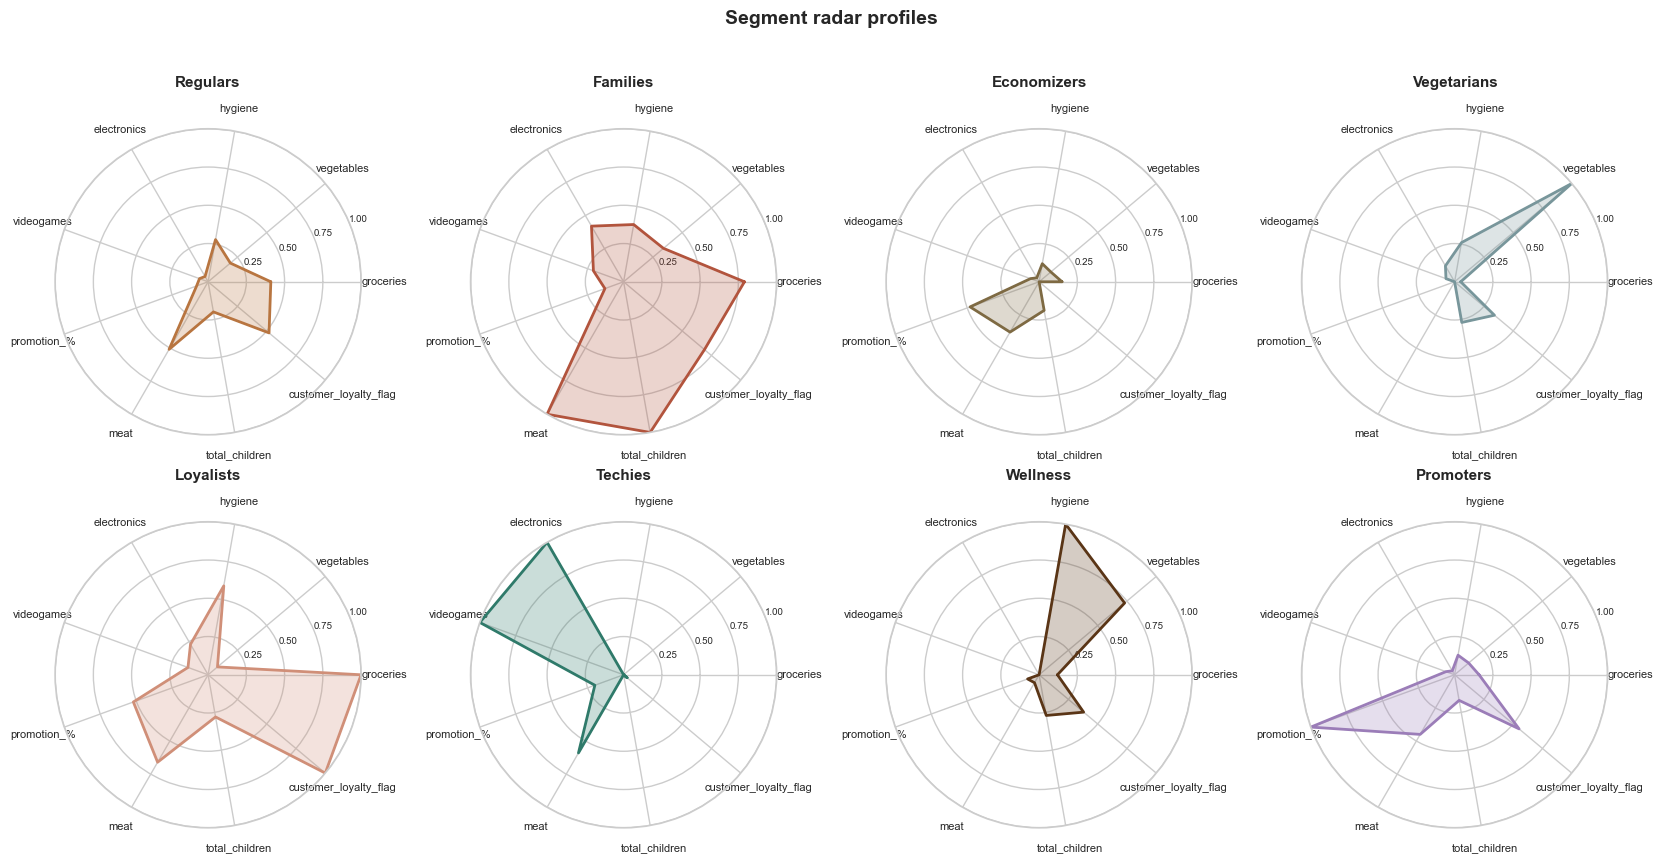

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_hygiene,lifetime_spend_electronics,lifetime_spend_videogames,percentage_of_products_bought_promotion,lifetime_spend_meat,total_children,customer_loyalty_flag
cluster,,,,,,,,,
0,0.41,0.19,0.28,0.04,0.06,0.08,0.51,0.20,0.52
1,0.79,0.34,0.38,0.42,0.21,0.13,1.00,1.00,0.69
2,0.15,0.10,0.12,0.03,0.06,0.48,0.38,0.19,0.00
3,0.04,1.00,0.26,0.12,0.06,0.00,0.00,0.27,0.34
4,1.00,0.08,0.59,0.23,0.14,0.52,0.66,0.28,1.00
5,0.00,0.00,0.00,1.00,1.00,0.20,0.59,0.00,0.03
6,0.12,0.73,1.00,0.00,0.00,0.08,0.06,0.27,0.38
7,0.16,0.12,0.13,0.03,0.06,1.00,0.45,0.17,0.55


In [77]:
radar_features = [
    "lifetime_spend_groceries",
    "lifetime_spend_vegetables",
    "lifetime_spend_hygiene",
    "lifetime_spend_electronics",
    "lifetime_spend_videogames",
    "percentage_of_products_bought_promotion",
    "lifetime_spend_meat",
    "total_children",
    "customer_loyalty_flag",
]

radar_profile = ucc.plot_radar_profiles(
    combined_profile,
    features=radar_features,
    cluster_names=ucc.CLUSTER_NAMES,
    title="Segment radar profiles",
)
display(radar_profile)


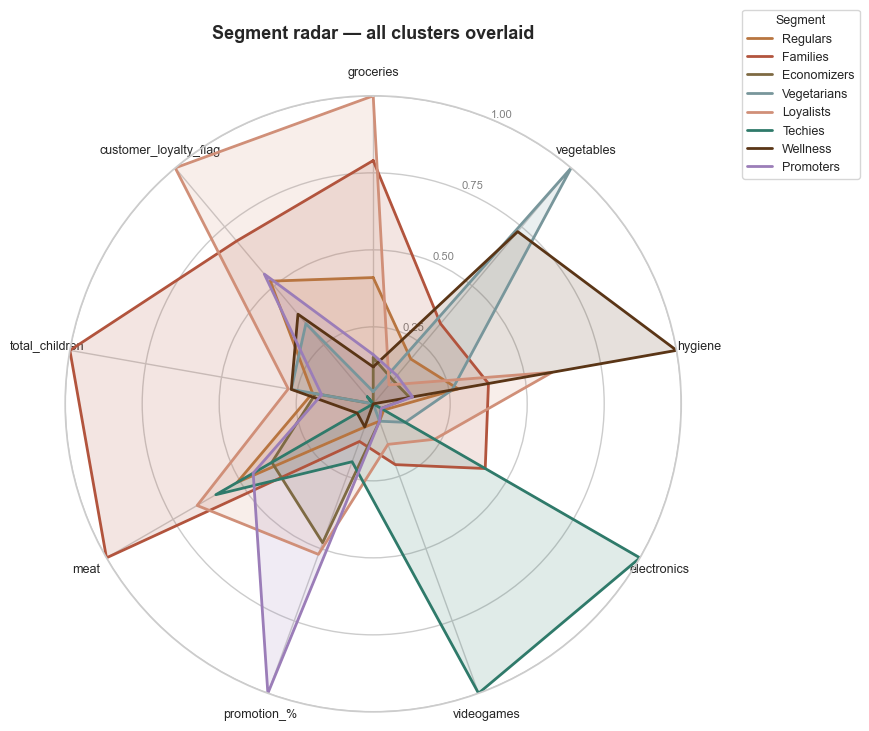

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_hygiene,lifetime_spend_electronics,lifetime_spend_videogames,percentage_of_products_bought_promotion,lifetime_spend_meat,total_children,customer_loyalty_flag
cluster,,,,,,,,,
0,0.41,0.19,0.28,0.04,0.06,0.08,0.51,0.20,0.52
1,0.79,0.34,0.38,0.42,0.21,0.13,1.00,1.00,0.69
2,0.15,0.10,0.12,0.03,0.06,0.48,0.38,0.19,0.00
3,0.04,1.00,0.26,0.12,0.06,0.00,0.00,0.27,0.34
4,1.00,0.08,0.59,0.23,0.14,0.52,0.66,0.28,1.00
5,0.00,0.00,0.00,1.00,1.00,0.20,0.59,0.00,0.03
6,0.12,0.73,1.00,0.00,0.00,0.08,0.06,0.27,0.38
7,0.16,0.12,0.13,0.03,0.06,1.00,0.45,0.17,0.55


In [78]:
ucc.plot_radar_combined(
    combined_profile,
    features=radar_features,
    cluster_names=ucc.CLUSTER_NAMES,
    title="Segment radar — all clusters overlaid",
)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Feature by feature plots</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The barplots and boxplots check whether the differences observed in the profile tables are clear across the distribution or mainly driven by extreme values.</p>
</div>

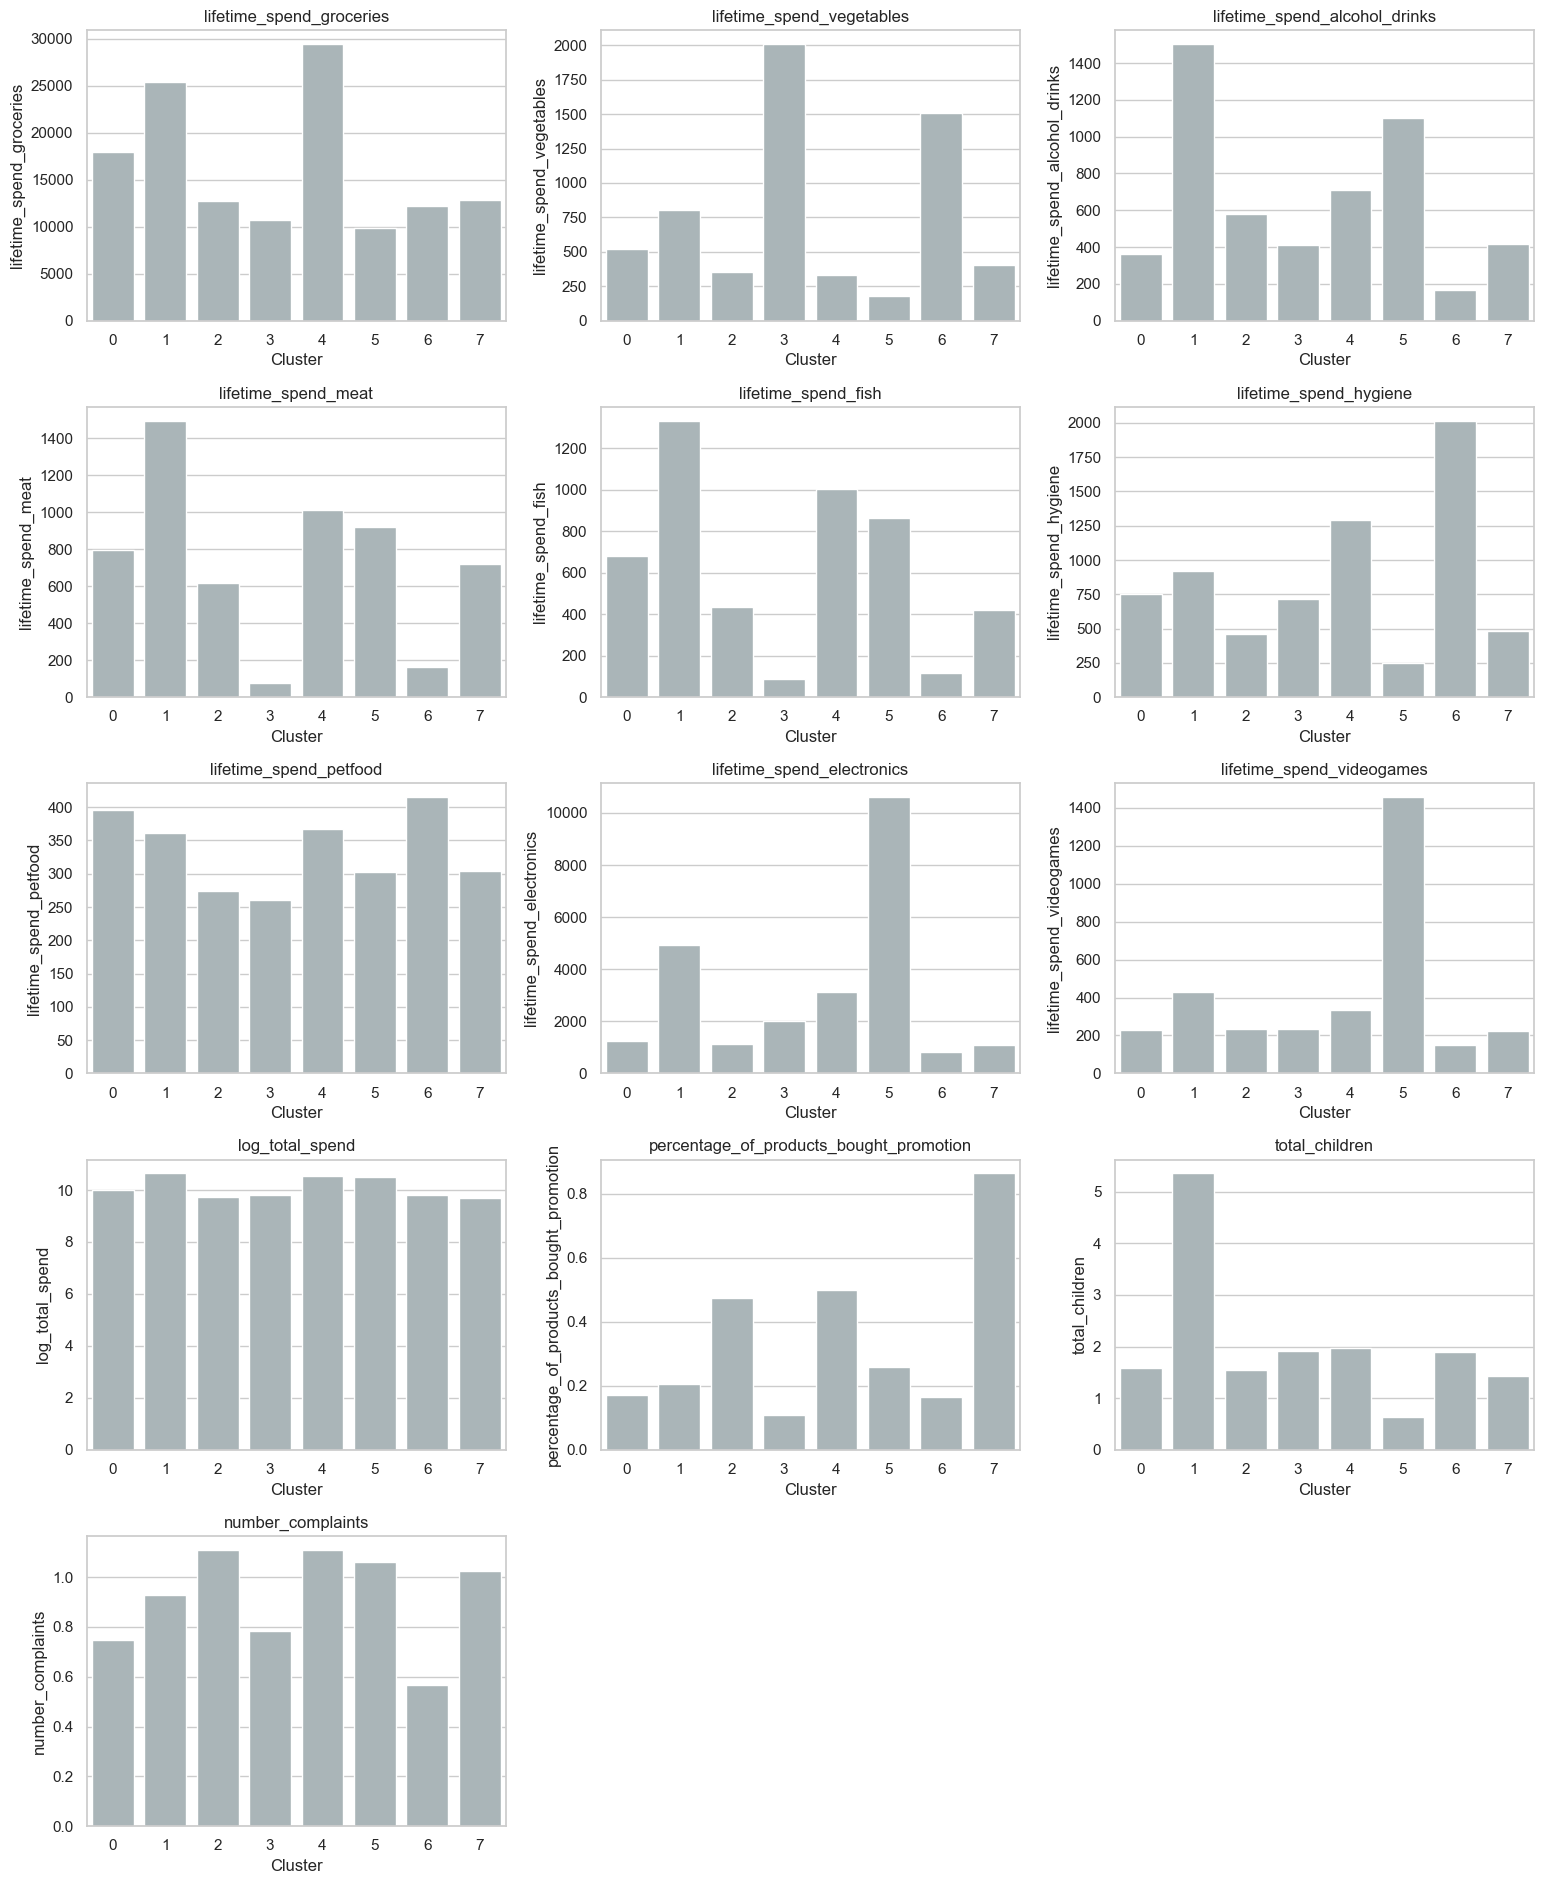

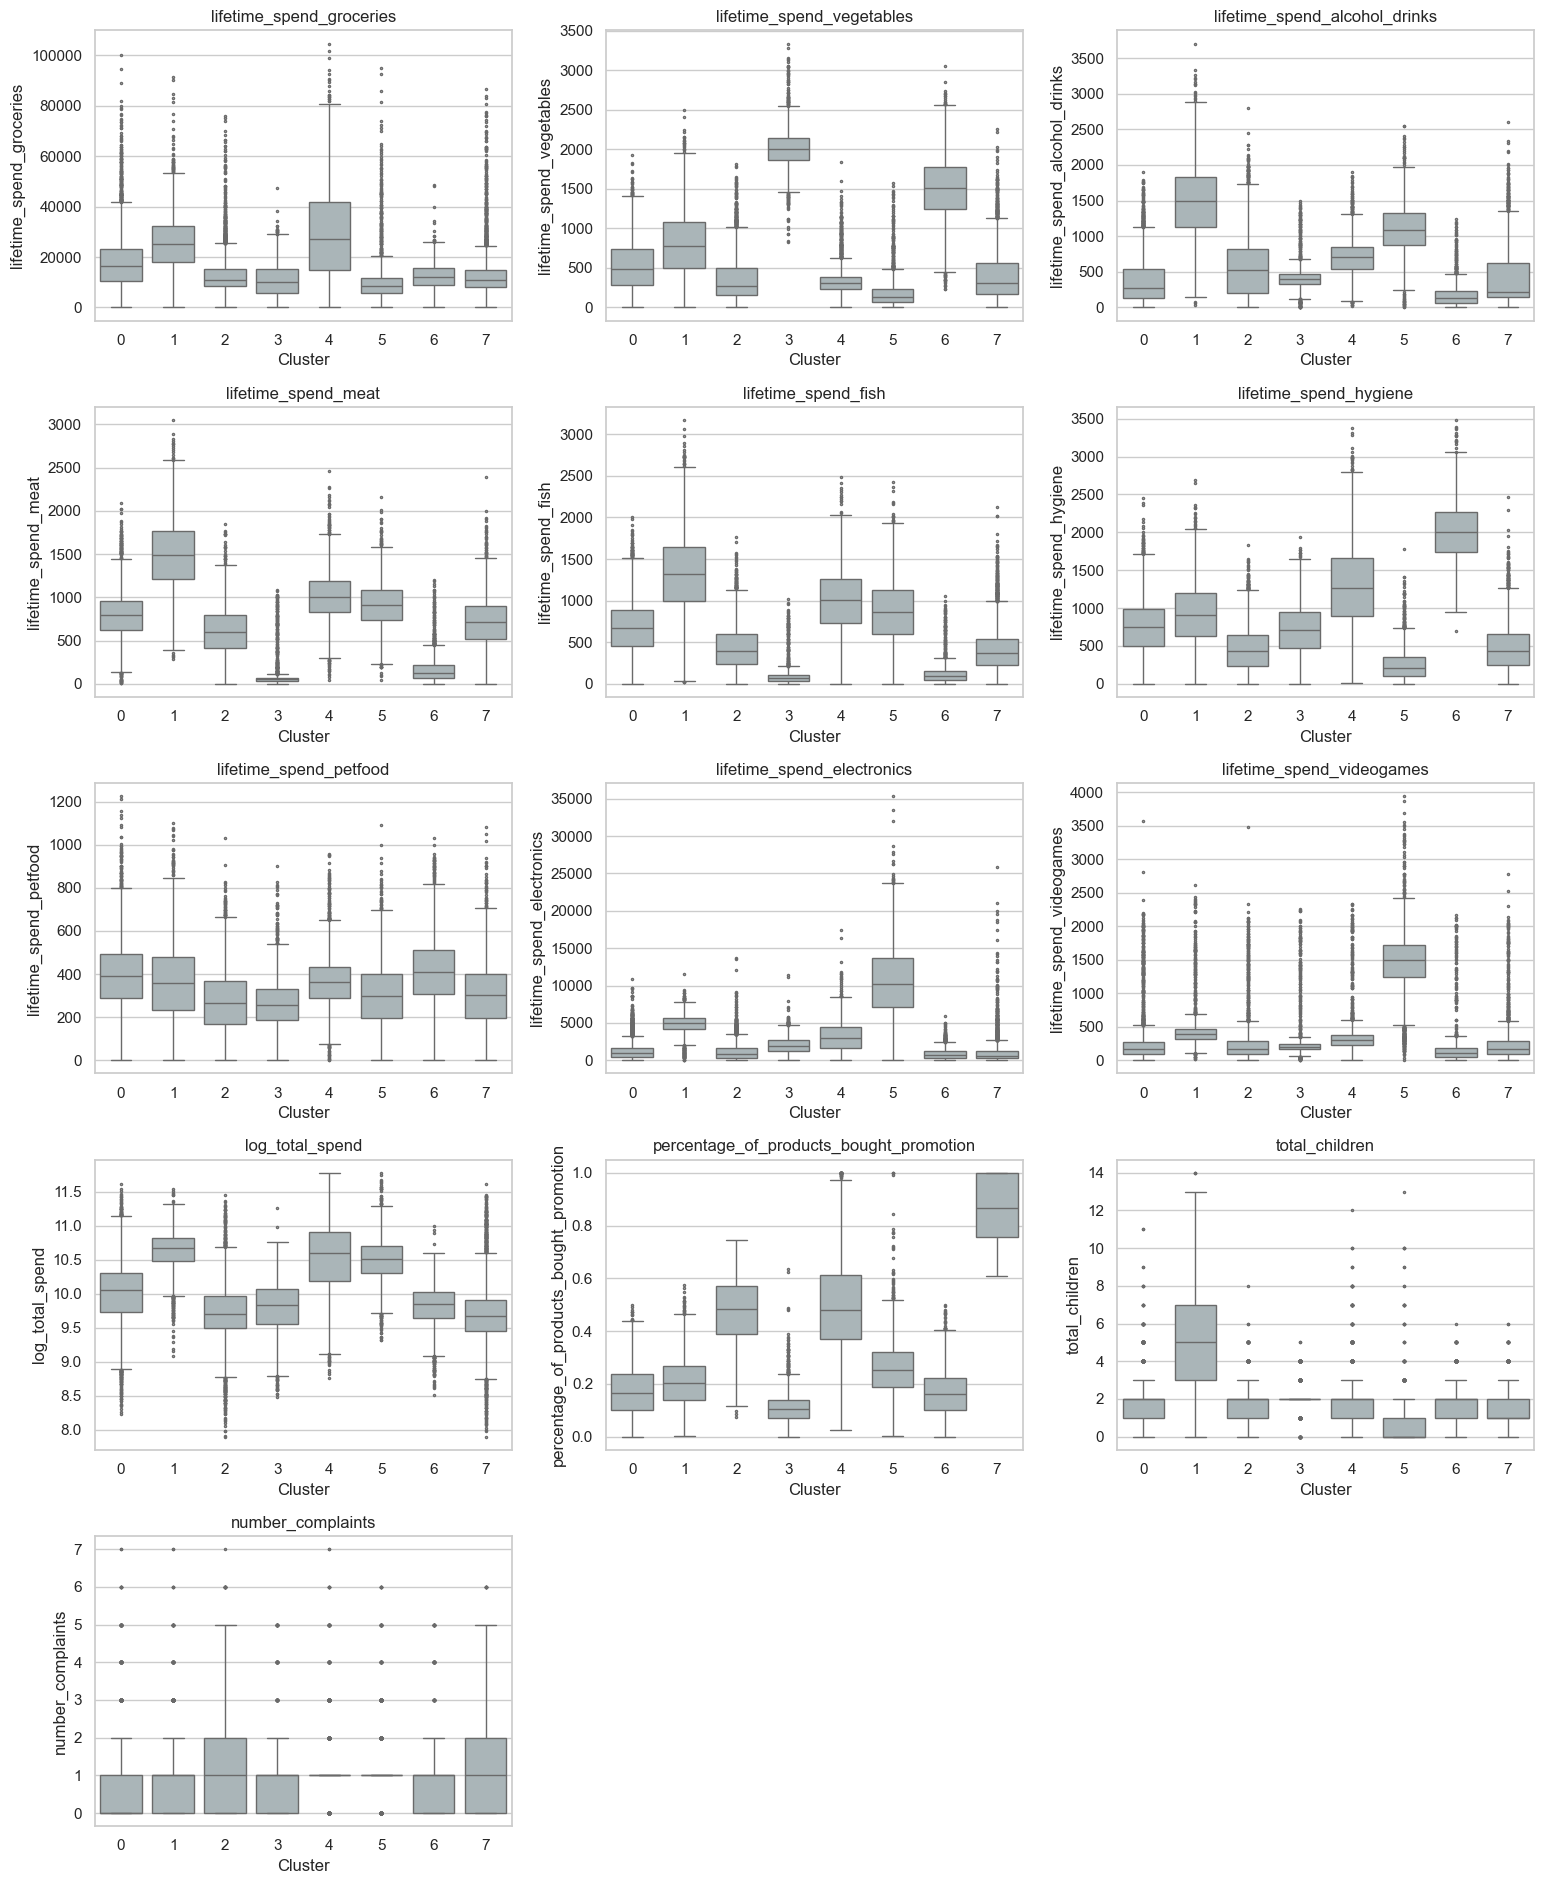

In [79]:
key_plot_cols = ucc.key_plot_columns(df)
ucc.plot_feature_bars(df, key_plot_cols)
ucc.plot_boxplot_grid(df, key_plot_cols)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Main differentiators by cluster</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The following table lists the largest relative differences from the overall customer base. It is used as a compact evidence table for cluster naming.</p>
</div>

In [80]:
deviations = ucc.top_deviations(combined_profile, n=6)
display(deviations)


,cluster,feature,relative_difference_%,cluster_mean,overall_mean
0,0,lifetime_spend_electronics,-54.8,1250.77,2764.96
1,0,percentage_of_products_bought_promotion,-51.4,0.17,0.35
2,0,lifetime_spend_alcohol_drinks,-41.8,362.21,622.00
3,0,lifetime_spend_videogames,-38.8,228.95,374.20
4,0,lifetime_spend_vegetables,-28.4,521.22,727.51
5,0,lifetime_spend_nonalcohol_drinks,-27.0,339.12,464.35
6,1,total_children,168.8,5.35,1.99
7,1,lifetime_spend_alcohol_drinks,141.5,1502.20,622.00
8,1,lifetime_spend_fish,119.1,1332.62,608.14
9,1,lifetime_spend_meat,106.5,1494.33,723.78


### 6.2 - Cluster summary cards

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Each card shows three views of one segment: a segment profile radar on the left, the top deviations from the overall mean in the centre, and a stats summary on the right.
</div>

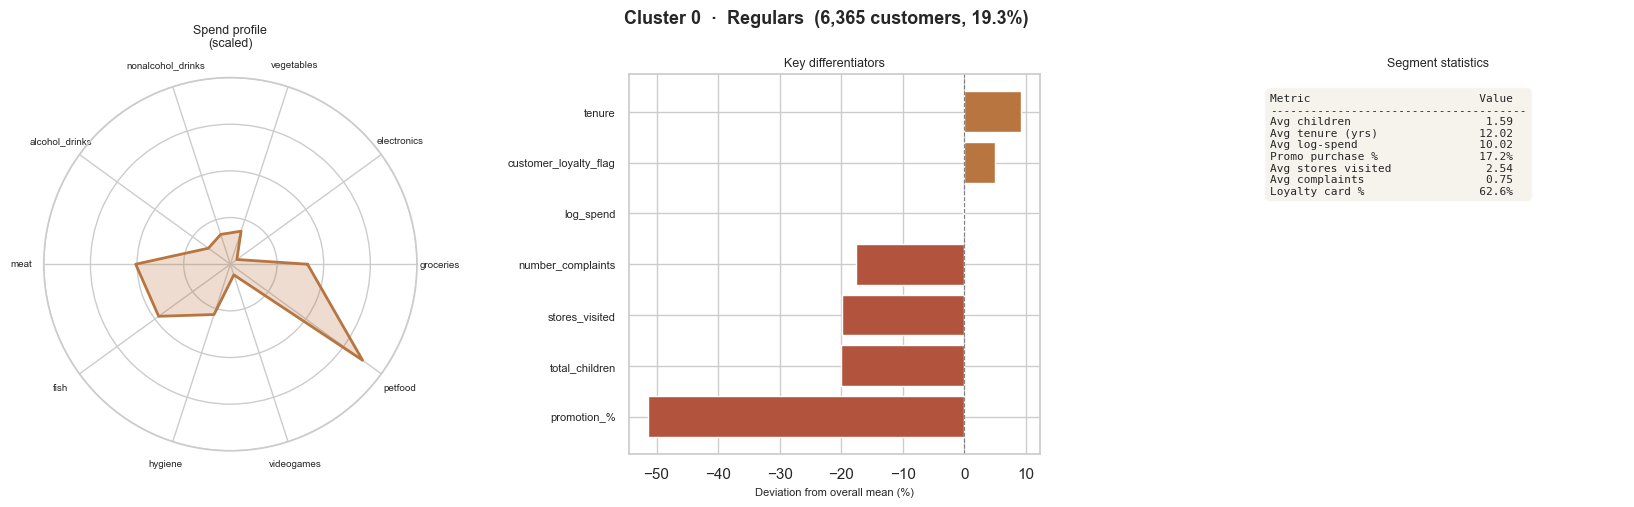

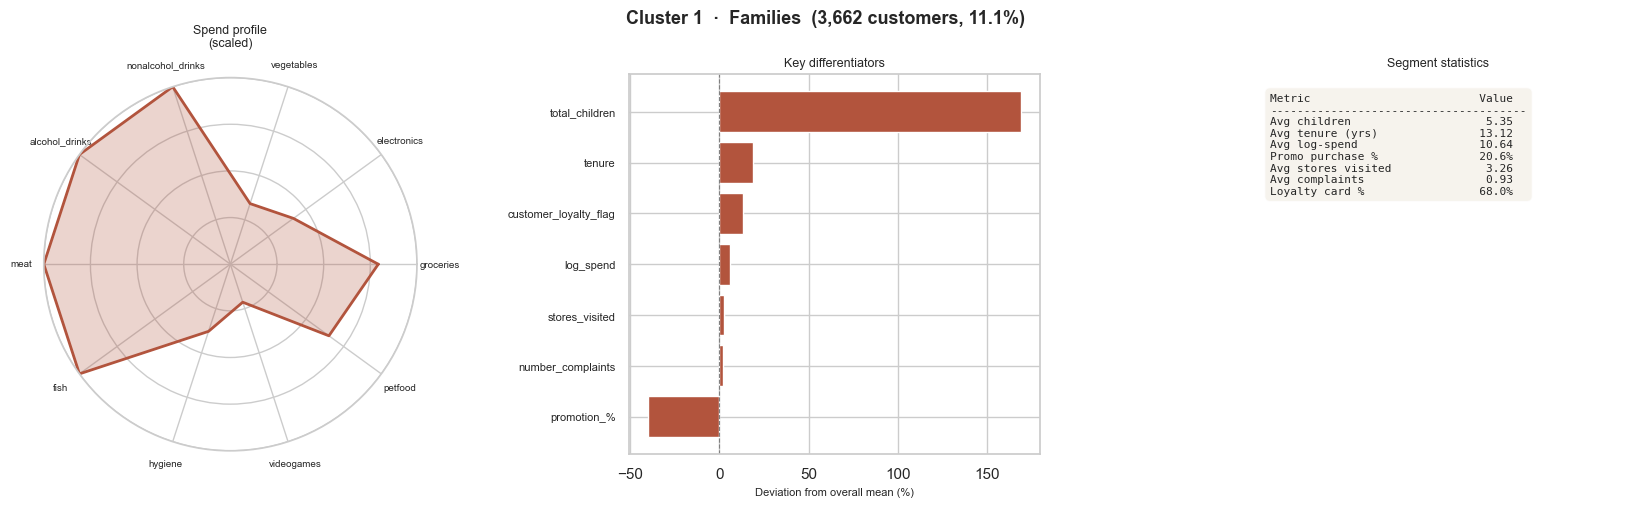

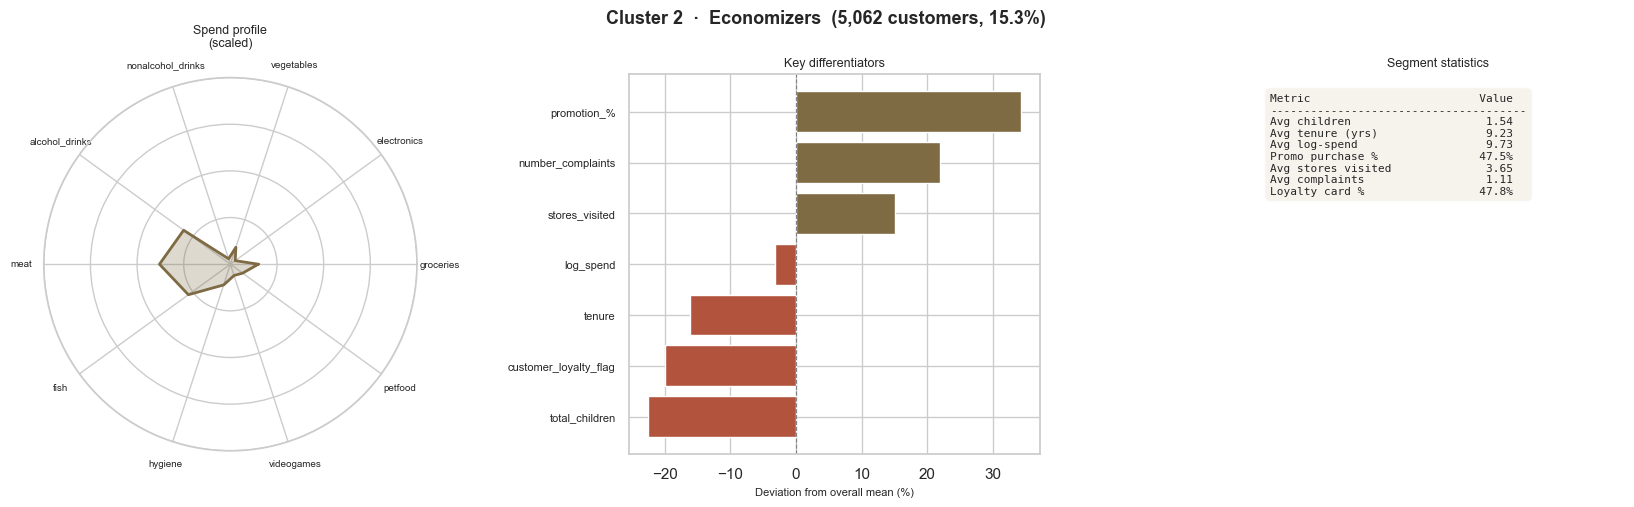

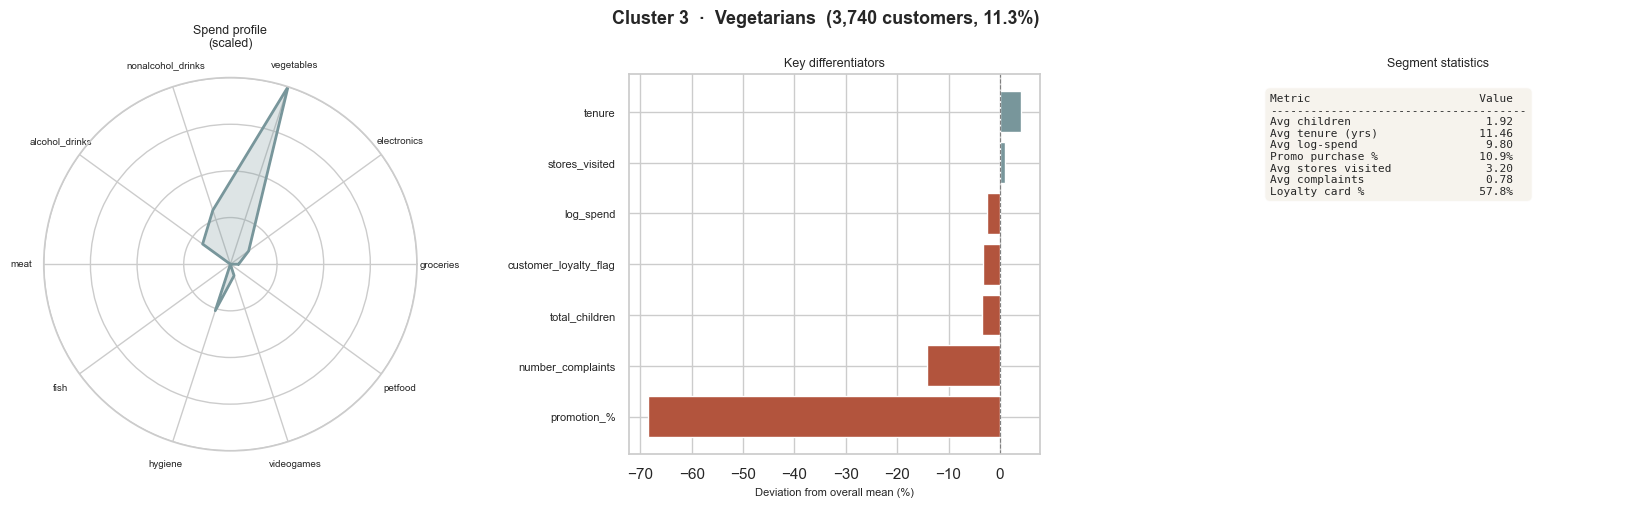

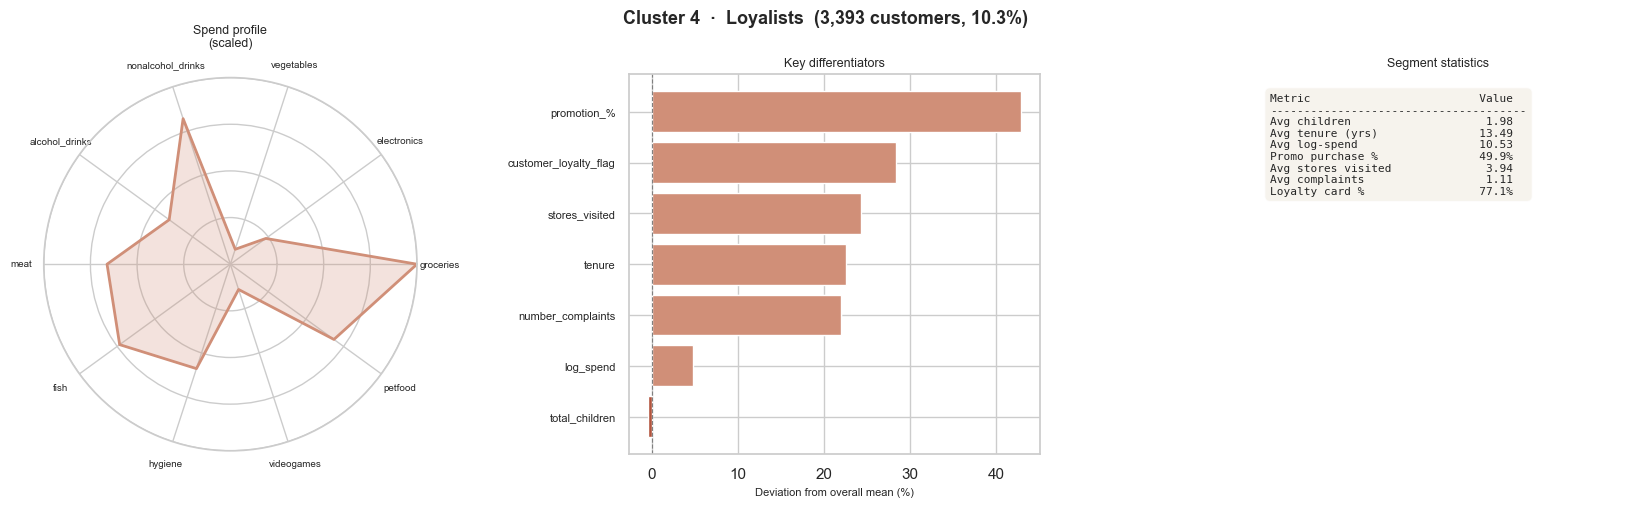

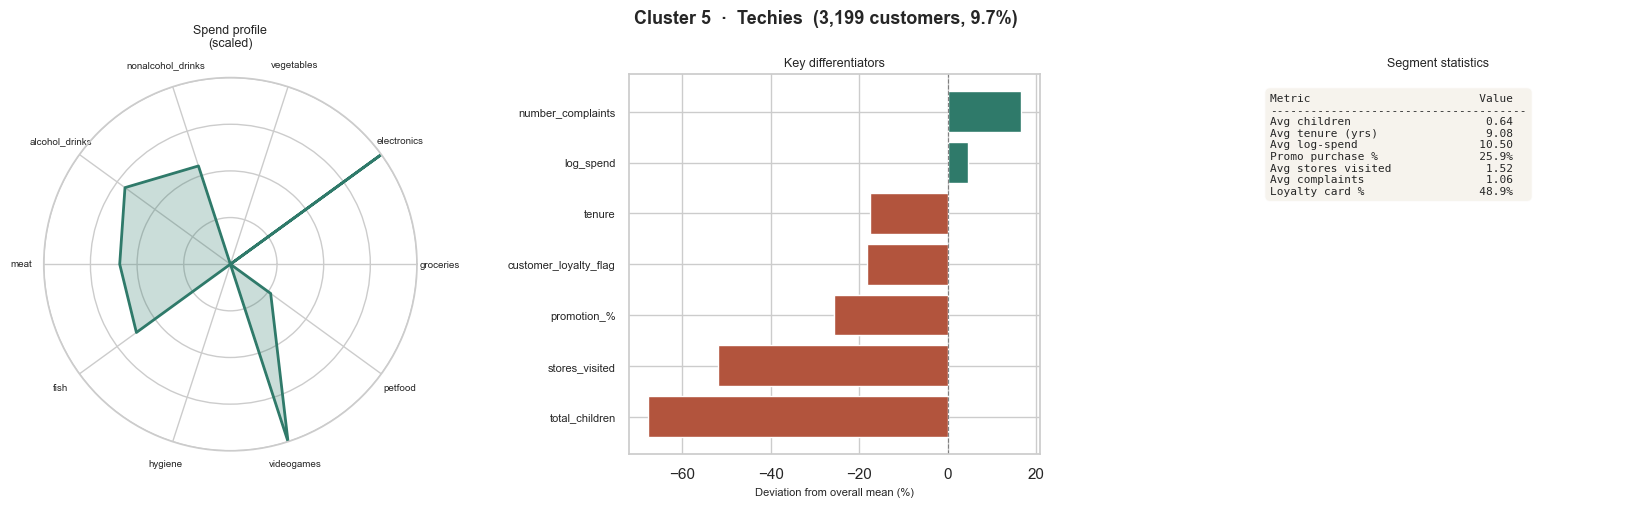

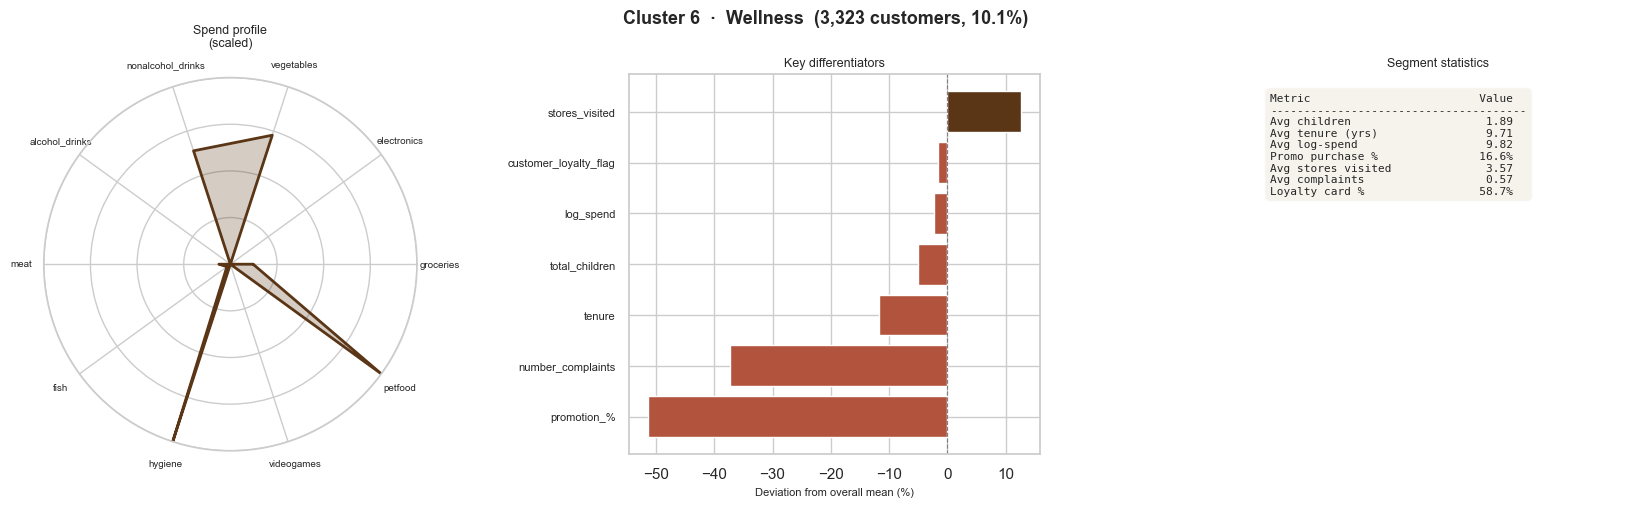

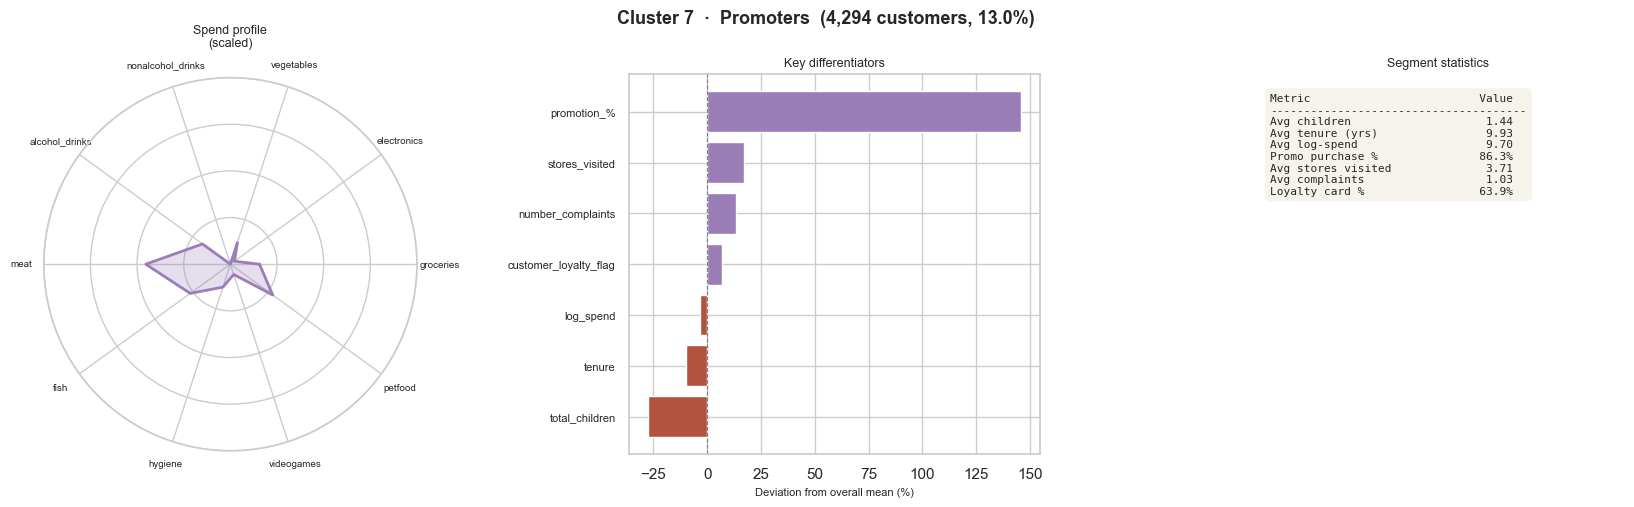

In [81]:
ucc.plot_all_cluster_cards(
    df,
    combined_profile,
    cluster_col='cluster',
    cluster_names=ucc.CLUSTER_NAMES,
)

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9) Cluster interpretation and naming rationale</b></h2>
<p style="color:#D8C0B4; margin:6px 0 14px 0;">
The final names are assigned after combining the normalised comparison, the deviation table and the original spend profiles. A cluster name is selected only when the same interpretation appears across several variables. This avoids naming a segment from one isolated feature and keeps the labels useful for business discussion.
</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>How the final names are chosen.</b><br><br>
The final name of each segment is chosen only when the same pattern appears in more than one view. For example, a customer group is not named after a product category just because one chart is high; the name must also be coherent with the deviation table, the original profile and the broader business interpretation.
</div>

<table style="width:100%; border-collapse:collapse; color:#F3EEE6; font-size:14px;">
<thead>
<tr style="border-bottom:1px solid #D8C0B4;">
<th style="text-align:left; padding:8px;">Cluster</th>
<th style="text-align:left; padding:8px;">Segment name</th>
<th style="text-align:left; padding:8px;">Main evidence</th>
<th style="text-align:left; padding:8px;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>0</b></td><td style="padding:8px;"><b>Regulars</b></td><td style="padding:8px;">No dominant category; under-indexes on all high-value spend dimensions (electronics, alcohol, videogames) and moderate promotion use.</td><td style="padding:8px;">A broad baseline segment with no strongly distinctive behaviour. Commercially useful as a reference group against more specialised segments.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>1</b></td><td style="padding:8px;"><b>Families</b></td><td style="padding:8px;">Highest children count (+169% vs overall), highest meat and fish spend, highest product diversity, and very high total spend.</td><td style="padding:8px;">Large households with broad stock-up needs. Their high basket value across food categories reflects multi-person purchasing.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>2</b></td><td style="padding:8px;"><b>Economizers</b></td><td style="padding:8px;">Under-indexes on most spend categories (electronics, vegetables, hygiene, videogames); moderately higher promotion use (+34%) and lowest loyalty flag rate.</td><td style="padding:8px;">Low-spend customers with limited basket diversification. Their higher promo usage reflects a value-seeking rather than brand-loyal shopping style.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>3</b></td><td style="padding:8px;"><b>Vegetarians</b></td><td style="padding:8px;">Highest vegetable spend (+176% vs overall), near-zero meat and fish spend, and lowest promotion purchase rate (-69%).</td><td style="padding:8px;">A clear plant-oriented basket profile defined both by what customers buy and deliberately avoid. Full-price, low-promotion shoppers.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>4</b></td><td style="padding:8px;"><b>Loyalists</b></td><td style="padding:8px;">Highest grocery spend (+80%), highest loyalty flag rate (77.6%), longest tenure (13.5 years), high fish and product diversity.</td><td style="padding:8px;">Established high-value customers with a long relationship with the retailer and a broad, grocery-anchored basket.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>5</b></td><td style="padding:8px;"><b>Techies</b></td><td style="padding:8px;">Highest electronics (+284%) and videogames (+289%) spend, fewest stores visited, and smallest household size (-68% children vs overall).</td><td style="padding:8px;">Specialised customers dominated by technology and entertainment purchases. Distinctly different basket from all other segments.</td></tr>
<tr style="border-bottom:1px solid rgba(216,192,180,0.35);"><td style="padding:8px;"><b>6</b></td><td style="padding:8px;"><b>Wellness</b></td><td style="padding:8px;">Highest hygiene spend (+146%), high vegetable spend (+107%), near-zero fish, meat, and alcohol spend, and low promotion use.</td><td style="padding:8px;">Health and personal care oriented shoppers who combine plant-based and hygiene categories and buy predominantly at full price.</td></tr>
<tr><td style="padding:8px;"><b>7</b></td><td style="padding:8px;"><b>Promoters</b></td><td style="padding:8px;">Highest promotion purchase rate (+146% vs overall), lowest total spend, and low values across most product categories.</td><td style="padding:8px;">Price-driven buyers whose defining trait is how they buy rather than what they buy. Promotion availability is their primary purchase trigger.</td></tr>
</tbody>
</table>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why there is no final Pets segment.</b><br><br>
A pet oriented alternative was tested in the clustering notebook. It produced a readable pet segment, but the global structure was slightly weaker and the final UMAP was less clean. The final naming therefore keeps petfood as a profiling insight rather than forcing it into the final segmentation. This decision favours a more stable eight cluster solution.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>10) Geographic check</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Latitude and longitude are used only for profiling. This plot checks whether any final segment is associated with a specific geographic concentration.</p>
</div>

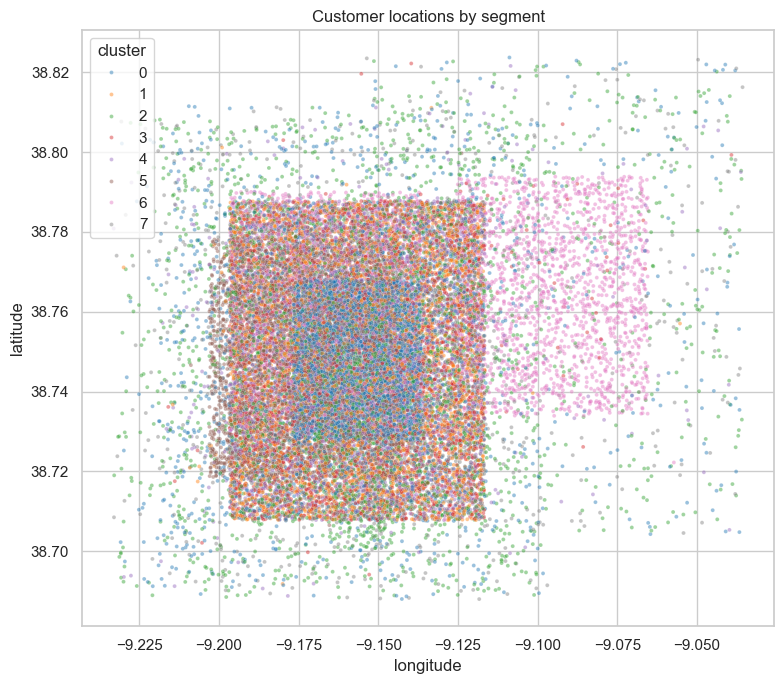

In [82]:
if {"latitude", "longitude"}.issubset(df.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=df, x="longitude", y="latitude", hue="cluster", palette="tab10", s=8, alpha=0.45)
    plt.title("Customer locations by segment")
    plt.tight_layout()
    plt.show()


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>11) Final segment names</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final names are assigned after reviewing the full profile of each cluster. The clustering distance uses selected purchase and promotion variables, while groceries, demographics, loyalty, household structure and complaints support interpretation. Petfood was reviewed during modelling, but it was not strong enough to replace the cleaner final solution.</p>
</div>


In [83]:
display(
    df[["cluster", "cluster_name"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)


,cluster,cluster_name
0,0,Regulars
1,1,Families
2,2,Economizers
3,3,Vegetarians
4,4,Loyalists
5,5,Techies
6,6,Wellness
7,7,Promoters


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>12) Export ID and cluster mapping</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final export keeps one row per customer with the numerical cluster and the corresponding business name. This file is the bridge between the modelling stage and any later business analysis, such as basket analysis or segment based recommendations.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why the mapping is exported.</b><br><br>
The modelling notebook exports numeric cluster labels because they are easier to reproduce and validate. This notebook adds the business names after the characterization step, creating a clean bridge between the technical segmentation and the final business interpretation.
</div>

In [84]:
id_cluster = ucc.export_id_cluster(df, f"{DATA_DIR}/id_and_cluster.csv")
print("Exported rows:", len(id_cluster))
id_cluster.head()


Exported rows: 33038


,customer_id,cluster,cluster_name
0,3,2,Economizers
1,4,6,Wellness
2,5,0,Regulars
3,7,5,Techies
4,8,5,Techies
